<a href="https://colab.research.google.com/github/Ajay-s2006/AI_Ml-Assigment/blob/main/ai_ml3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
path = kagglehub.dataset_download("pankeshpatel/homeprice")

100%|██████████| 216/216 [00:00<00:00, 594kB/s]

Extracting files...


### **Data Preparation**

First, I'll prepare the data by splitting it into features (X) and target (y), and then further divide it into training and testing sets.

In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df[['area']]
y = df['price']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 4 samples
Testing set size: 1 samples


### **1. Linear Regression**

Now, let's train a Linear Regression model, make predictions, and evaluate its performance.

### **2. Decision Tree Regression**

Next, let's train a Decision Tree Regressor model, make predictions, and evaluate its performance.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


Decision Tree Regression Performance:
  Mean Squared Error (MSE): 2025000000.00
  Root Mean Squared Error (RMSE): 45000.00
  Mean Absolute Error (MAE): 45000.00
  R-squared (R2): nan


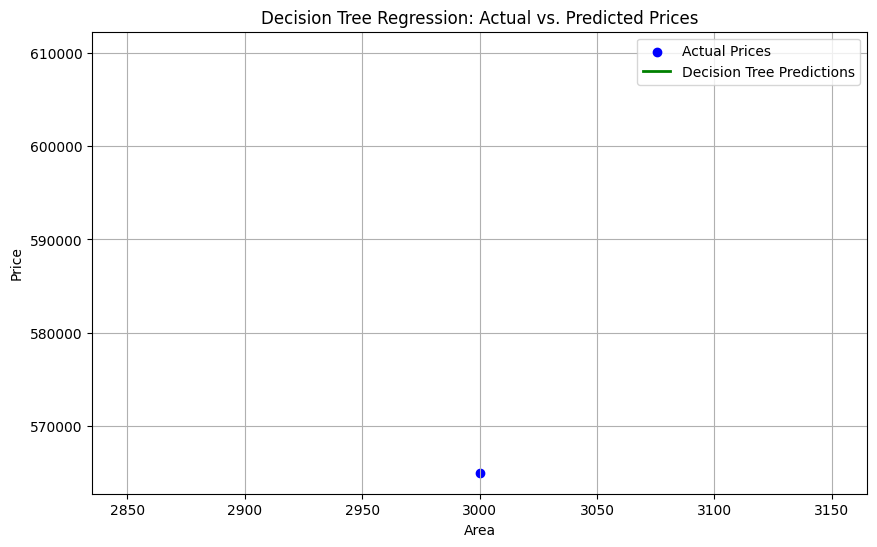

In [ ]:
from sklearn.tree import DecisionTreeRegressor

# Initialize and train the Decision Tree Regressor model
dt_reg_model = DecisionTreeRegressor(random_state=42)
dt_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_dt_reg = dt_reg_model.predict(X_test)

# Evaluate the model
mse_dt_reg = mean_squared_error(y_test, y_pred_dt_reg)
rmse_dt_reg = np.sqrt(mse_dt_reg)
mae_dt_reg = mean_absolute_error(y_test, y_pred_dt_reg)
r2_dt_reg = r2_score(y_test, y_pred_dt_reg)

print("Decision Tree Regression Performance:")
print(f"  Mean Squared Error (MSE): {mse_dt_reg:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_dt_reg:.2f}")
print(f"  Mean Absolute Error (MAE): {mae_dt_reg:.2f}")
print(f"  R-squared (R2): {r2_dt_reg:.2f}")

# Visualize predictions vs. actual values
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', label='Actual Prices')
plt.plot(X_test, y_pred_dt_reg, color='green', linewidth=2, label='Decision Tree Predictions')
plt.xlabel('Area')
plt.ylabel('Price')
plt.title('Decision Tree Regression: Actual vs. Predicted Prices')
plt.legend()
plt.grid(True)
plt.show()

### **3. Random Forest Regression**

Finally, let's train a Random Forest Regressor model, make predictions, and evaluate its performance.

### **Model Performance Comparison**

Let's compare the performance of Linear Regression, Decision Tree Regression, and Random Forest Regression models using Mean Absolute Error (MAE), Mean Squared Error (MSE), and Root Mean Squared Error (RMSE).

Model Performance Summary:


,Model,MAE,MSE,RMSE
0,Linear Regression,31355.140187,9.831448e+08,31355.140187
1,Decision Tree,45000.000000,2.025000e+09,45000.000000
2,Random Forest,29300.000000,8.584900e+08,29300.000000


/tmp/ipykernel_24378/3513360930.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='MAE', data=performance_df, ax=axes[0], palette='viridis')
/tmp/ipykernel_24378/3513360930.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='MSE', data=performance_df, ax=axes[1], palette='magma')
/tmp/ipykernel_24378/3513360930.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='RMSE', data=performance_df, ax=axes[2], palette='cividis')


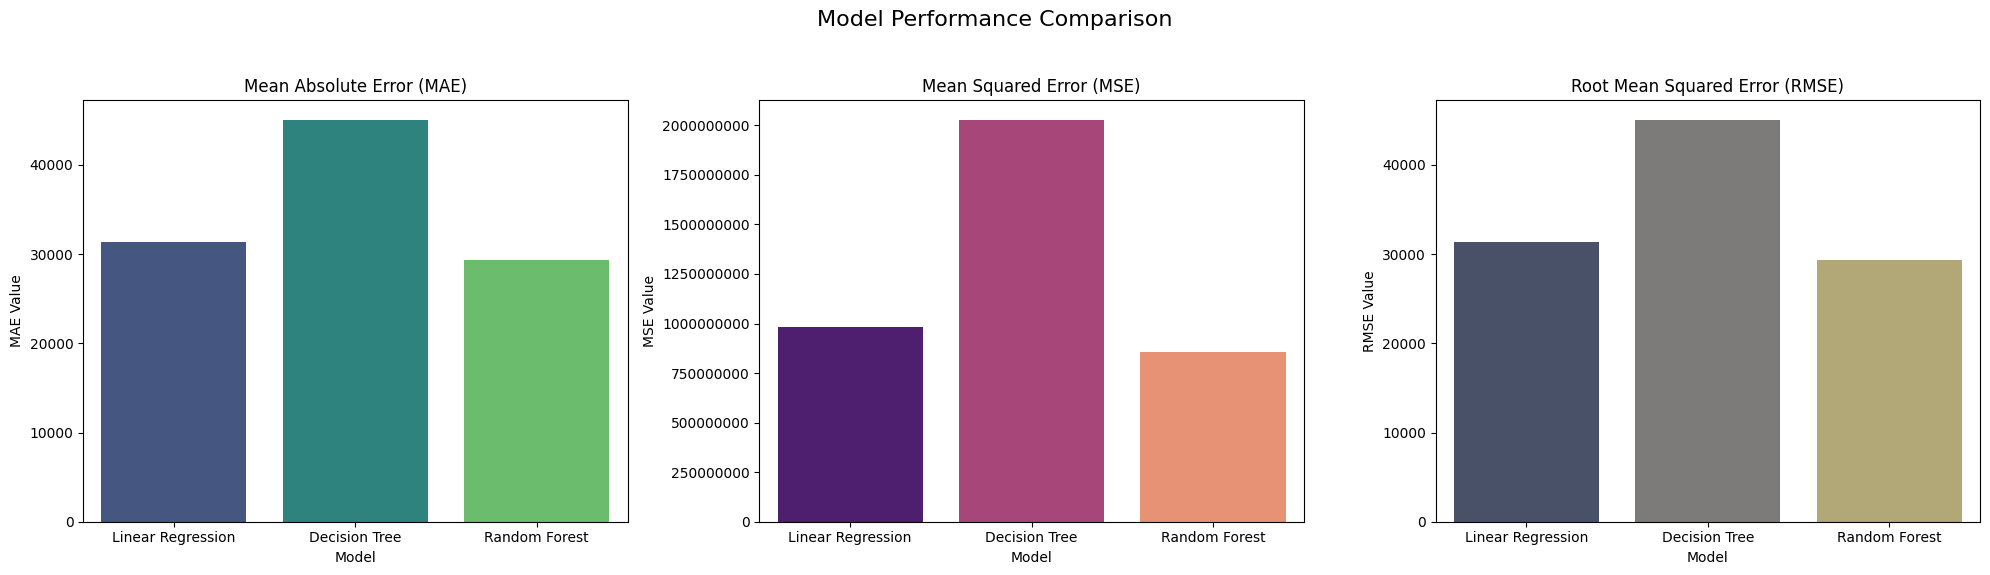

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Gather performance metrics
performance_data = {
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'MAE': [mae_lin_reg, mae_dt_reg, mae_rf_reg],
    'MSE': [mse_lin_reg, mse_dt_reg, mse_rf_reg],
    'RMSE': [rmse_lin_reg, rmse_dt_reg, rmse_rf_reg]
}

performance_df = pd.DataFrame(performance_data)

print("Model Performance Summary:")
display(performance_df)

# Plotting the performance metrics
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=False)
fig.suptitle('Model Performance Comparison', fontsize=16)

# MAE Plot
sns.barplot(x='Model', y='MAE', data=performance_df, ax=axes[0], palette='viridis')
axes[0].set_title('Mean Absolute Error (MAE)')
axes[0].set_ylabel('MAE Value')
axes[0].ticklabel_format(style='plain', axis='y')

# MSE Plot
sns.barplot(x='Model', y='MSE', data=performance_df, ax=axes[1], palette='magma')
axes[1].set_title('Mean Squared Error (MSE)')
axes[1].set_ylabel('MSE Value')
axes[1].ticklabel_format(style='plain', axis='y')

# RMSE Plot
sns.barplot(x='Model', y='RMSE', data=performance_df, ax=axes[2], palette='cividis')
axes[2].set_title('Root Mean Squared Error (RMSE)')
axes[2].set_ylabel('RMSE Value')
axes[2].ticklabel_format(style='plain', axis='y')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

As discussed, it's important to remember that these comparisons are based on an extremely small test set (1 sample) and may not accurately reflect the models' true performance on a larger, more representative dataset.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


Random Forest Regression Performance:
  Mean Squared Error (MSE): 858490000.00
  Root Mean Squared Error (RMSE): 29300.00
  Mean Absolute Error (MAE): 29300.00
  R-squared (R2): nan


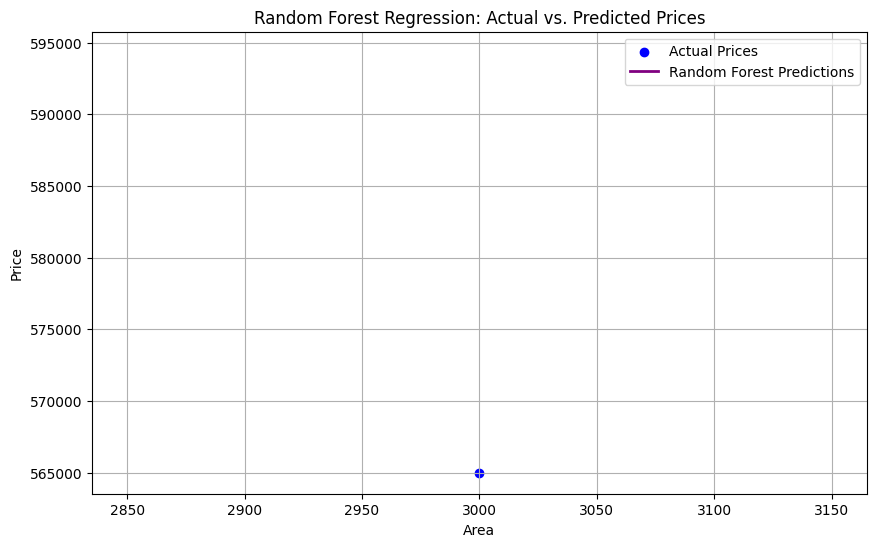

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the Random Forest Regressor model
rf_reg_model = RandomForestRegressor(random_state=42)
rf_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf_reg = rf_reg_model.predict(X_test)

# Evaluate the model
mse_rf_reg = mean_squared_error(y_test, y_pred_rf_reg)
rmse_rf_reg = np.sqrt(mse_rf_reg)
mae_rf_reg = mean_absolute_error(y_test, y_pred_rf_reg)
r2_rf_reg = r2_score(y_test, y_pred_rf_reg)

print("Random Forest Regression Performance:")
print(f"  Mean Squared Error (MSE): {mse_rf_reg:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_rf_reg:.2f}")
print(f"  Mean Absolute Error (MAE): {mae_rf_reg:.2f}")
print(f"  R-squared (R2): {r2_rf_reg:.2f}")

# Visualize predictions vs. actual values
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', label='Actual Prices')
plt.plot(X_test, y_pred_rf_reg, color='purple', linewidth=2, label='Random Forest Predictions')
plt.xlabel('Area')
plt.ylabel('Price')
plt.title('Random Forest Regression: Actual vs. Predicted Prices')
plt.legend()
plt.grid(True)
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


Linear Regression Performance:
  Mean Squared Error (MSE): 983144816.14
  Root Mean Squared Error (RMSE): 31355.14
  Mean Absolute Error (MAE): 31355.14
  R-squared (R2): nan


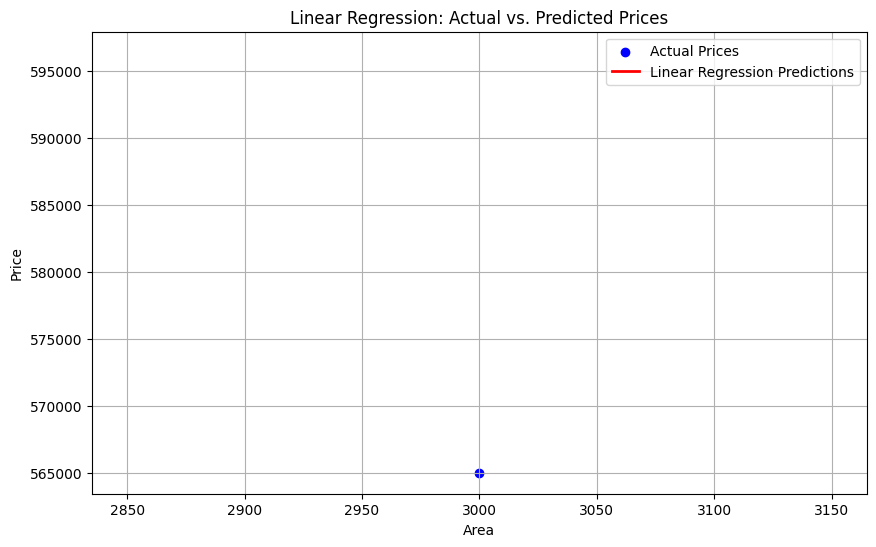

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np

# Initialize and train the Linear Regression model
lin_reg_model = LinearRegression()
lin_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lin_reg = lin_reg_model.predict(X_test)

# Evaluate the model
mse_lin_reg = mean_squared_error(y_test, y_pred_lin_reg)
rmse_lin_reg = np.sqrt(mse_lin_reg)
mae_lin_reg = mean_absolute_error(y_test, y_pred_lin_reg)
r2_lin_reg = r2_score(y_test, y_pred_lin_reg)

print("Linear Regression Performance:")
print(f"  Mean Squared Error (MSE): {mse_lin_reg:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_lin_reg:.2f}")
print(f"  Mean Absolute Error (MAE): {mae_lin_reg:.2f}")
print(f"  R-squared (R2): {r2_lin_reg:.2f}")

# Visualize predictions vs. actual values
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', label='Actual Prices')
plt.plot(X_test, y_pred_lin_reg, color='red', linewidth=2, label='Linear Regression Predictions')
plt.xlabel('Area')
plt.ylabel('Price')
plt.title('Linear Regression: Actual vs. Predicted Prices')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import os
import pandas as pd

# The 'path' variable contains the directory where the dataset was downloaded.
# We need to find the actual data file (e.g., CSV) within this directory.
# Let's assume there's a CSV file in the downloaded path.

# List files in the downloaded directory to find the data file
files_in_dir = os.listdir(path)
print(f"Files in the downloaded directory '{path}': {files_in_dir}")

# Try to find a CSV file and load it
csv_file = None
for f in files_in_dir:
    if f.endswith('.csv'):
        csv_file = os.path.join(path, f)
        break

if csv_file:
    print(f"Loading data from: {csv_file}")
    df = pd.read_csv(csv_file)
    print("Dataset loaded successfully.")
    print("First 5 rows of the dataset:")
    display(df.head())
else:
    print("No CSV file found in the downloaded directory. Please check the dataset content.")

Files in the downloaded directory '/root/.cache/kagglehub/datasets/pankeshpatel/homeprice/versions/1': ['homeprices.csv']
Loading data from: /root/.cache/kagglehub/datasets/pankeshpatel/homeprice/versions/1/homeprices.csv
Dataset loaded successfully.
First 5 rows of the dataset:


,area,price
0,2600,550000
1,3000,565000
2,3200,610000
3,3600,680000
4,4000,725000
